# 10 — Learned trade/no-trade thresholds

Learn a gate for the W3 **development-only statistical survivor**
(`negative_share`), not a return forecast. That signal failed the transaction-
cost test, so this is an exploratory capacity check rather than a validated
alpha refinement.
The direction remains the within-session rank of economically oriented
negative share. The target is whether that direction earns a positive h1
abnormal return.

**Chronology.** Fit through 2017; choose the fixed band and probability cutoff
on 2018–2019. The corrected run is one valid 2020–2023 disclosure after
one void pre-repair read whose one-sided books violated the declared
neutrality contract. Costs are 10 bps/side;
evaluation net-mean intervals use a 20-session circular block bootstrap
(999 replications, seed 20260731).

**Portfolio contract.** The gate may retain an asymmetric set of names. The
surviving positive and negative rank legs are therefore normalised separately
to +0.5 and −0.5 gross; a one-sided selected set goes flat. This preserves the
original direction while preventing a gate from becoming a hidden market bet.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import roc_auc_score

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.plots import display_label  # noqa: E402
from final_experiments.lib.thresholds import (  # noqa: E402
    FEATURES,
    MIN_ACTIVE_SESSION_SHARE,
    MIN_MEAN_ACTIVE,
    SEED,
    choose_fixed_band,
    choose_probability_cutoff,
    gate_daily_portfolio,
    make_models,
    portfolio_summary,
    prepare_gate_frame,
    split_gate_frame,
)

OUTPUT = REPO_ROOT / "final_experiments" / "outputs" / "10_thresholds"
OUTPUT.mkdir(parents=True, exist_ok=True)
AGG_PATH = REPO_ROOT / "final_experiments" / "outputs" / "03_aggregation" / "firm_day_aggregators.parquet"
SURPRISE_PATH = REPO_ROOT / "final_experiments" / "outputs" / "04_surprise" / "firm_day_surprise.parquet"

print("fit: <=2017-12-31; validation: 2018-01-01..2019-12-31; evaluation: >=2020-01-01")
print("models: fixed band, logistic, gradient boosted, small MLP, shuffled-label MLP")
print("seed:", SEED)
print("cost: 10 bps/side; inference: 20-session block bootstrap")
print(f"cutoff eligibility: mean active >= {MIN_MEAN_ACTIVE:g}, active-session share >= {MIN_ACTIVE_SESSION_SHARE:.0%}")

fit: <=2017-12-31; validation: 2018-01-01..2019-12-31; evaluation: >=2020-01-01
models: fixed band, logistic, gradient boosted, small MLP, shuffled-label MLP
seed: 20260731
cost: 10 bps/side; inference: 20-session block bootstrap
cutoff eligibility: mean active >= 5, active-session share >= 50%


In [2]:
agg = pd.read_parquet(AGG_PATH)
surprise = pd.read_parquet(SURPRISE_PATH)
frame = prepare_gate_frame(agg, surprise)
train, validation, evaluation = split_gate_frame(frame)
print(f"train={len(train):,}; validation={len(validation):,}; evaluation={len(evaluation):,}")
print("features:", FEATURES)

train=360,489; validation=151,660; evaluation=203,374
features: ('oriented_rank', 'abs_oriented_rank', 'log_article_count', 'dispersion', 'mean_continuous', 'firm_baseline', 'cs_mean', 'ret_lag1')


## Fixed-band baseline first

The historical evaluation keeps its originally selected fixed band. For the
next genuinely new sample, the fixed baseline must satisfy the same activity
floor as the learned gates; otherwise a nearly always-cash rule gets an unfair
advantage.

In [3]:
fixed_band, fixed_sweep = choose_fixed_band(validation, require_activity=False)
activity_matched_fixed_band, _ = choose_fixed_band(validation, require_activity=True)
fixed_sweep.to_csv(OUTPUT / "fixed_band_validation_sweep.csv", index=False)
display(fixed_sweep.round(6))
print("historical frozen fixed band:", fixed_band)
print("activity-matched fixed band for the next sample:", activity_matched_fixed_band)

,band,n_sessions,mean_active,active_session_share,mean_net_exposure,mean_gross,mean_net,mean_turnover,gross_sharpe,net_sharpe,breakeven_bps_per_side,net_mean_ci_low,net_mean_ci_high,bootstrap_block_length,bootstrap_replications,bootstrap_seed,selection_eligible
0,0.0,503,301.510934,1.000000,-0.0,0.000053,-0.001277,0.664772,0.426964,-10.295545,0.398698,-0.001450,-0.001104,20,999,20260731,True
1,0.2,503,256.512922,0.842942,-0.0,-0.000028,-0.001216,0.594050,-0.252878,-10.871245,-0.235118,-0.001385,-0.001064,20,999,20260731,True
2,0.4,503,8.421471,0.029821,0.0,0.000024,-0.000034,0.029041,1.347187,-1.855713,4.078085,-0.000069,-0.000006,20,999,20260731,False
3,0.6,503,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.000000,0.000000,20,999,20260731,False
4,0.8,503,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.000000,0.000000,20,999,20260731,False


historical frozen fixed band: 0.4
activity-matched fixed band for the next sample: 0.0


## Fit the three declared learned gates

In [4]:
x_train = train[list(FEATURES)]
y_train = train["target_correct_direction"]
x_validation = validation[list(FEATURES)]
x_evaluation = evaluation[list(FEATURES)]

models = make_models(SEED)
frozen = []
cutoff_sweeps = []
probabilities = {}
for name, model in models.items():
    print("fitting", name)
    model.fit(x_train, y_train)
    p_validation = model.predict_proba(x_validation)[:, 1]
    cutoff, sweep = choose_probability_cutoff(validation, p_validation)
    sweep.insert(0, "model", name)
    cutoff_sweeps.append(sweep)
    probabilities[(name, "validation")] = p_validation
    probabilities[(name, "evaluation")] = model.predict_proba(x_evaluation)[:, 1]
    frozen.append(
        {
            "model": name,
            "probability_cutoff": cutoff,
            "validation_auc": roc_auc_score(validation["target_correct_direction"], p_validation),
        }
    )

cutoff_table = pd.concat(cutoff_sweeps, ignore_index=True)
cutoff_table.to_csv(OUTPUT / "learned_gate_validation_sweeps.csv", index=False)
frozen_table = pd.DataFrame(frozen)
frozen_table.to_csv(OUTPUT / "frozen_gate_specs.csv", index=False)
display(frozen_table.round(6))

fitting logistic


fitting gradient_boosted


fitting mlp


,model,probability_cutoff,validation_auc
0,logistic,0.500,0.505994
1,gradient_boosted,0.500,0.505612
2,mlp,0.525,0.503928


## Label-shuffle capacity control

In [5]:
rng = np.random.default_rng(SEED)
shuffled_y = rng.permutation(y_train.to_numpy())
shuffled = make_models(SEED)["mlp"]
shuffled.fit(x_train, shuffled_y)
p_shuffle_validation = shuffled.predict_proba(x_validation)[:, 1]
shuffle_cutoff, shuffle_sweep = choose_probability_cutoff(validation, p_shuffle_validation)
shuffle_sweep.insert(0, "model", "mlp_label_shuffle")
shuffle_sweep.to_csv(OUTPUT / "label_shuffle_validation_sweep.csv", index=False)
p_shuffle_evaluation = shuffled.predict_proba(x_evaluation)[:, 1]
print("shuffled-label MLP cutoff:", shuffle_cutoff)

shuffled-label MLP cutoff: 0.525


## Recomputed historical and activity-matched evaluation comparison

This preserves the originally selected fixed-band arm and, with explicit
authorisation to continue iterating, recomputes the activity-matched band on
the already inspected 2020–2023 block. The added arm is labelled retrospective.
All arms include final liquidation turnover, matching notebook 06's accounting
convention. Cash is shown as an admissible deployment comparator.

In [6]:
rows = []
fixed_daily = gate_daily_portfolio(
    evaluation,
    evaluation["abs_oriented_rank"] > fixed_band,
)
rows.append({"arm": "fixed_band_historical", "threshold": fixed_band, **portfolio_summary(fixed_daily)})

activity_matched_daily = gate_daily_portfolio(
    evaluation,
    evaluation["abs_oriented_rank"] > activity_matched_fixed_band,
)
rows.append(
    {
        "arm": "fixed_band_activity_matched_iterative",
        "threshold": activity_matched_fixed_band,
        **portfolio_summary(activity_matched_daily),
    }
)

for spec in frozen:
    name = spec["model"]
    cutoff = float(spec["probability_cutoff"])
    daily = gate_daily_portfolio(evaluation, probabilities[(name, "evaluation")] >= cutoff)
    rows.append(
        {
            "arm": name,
            "threshold": cutoff,
            "evaluation_auc": roc_auc_score(evaluation["target_correct_direction"], probabilities[(name, "evaluation")]),
            **portfolio_summary(daily),
        }
    )

shuffle_daily = gate_daily_portfolio(evaluation, p_shuffle_evaluation >= shuffle_cutoff)
rows.append(
    {
        "arm": "mlp_label_shuffle",
        "threshold": shuffle_cutoff,
        "evaluation_auc": roc_auc_score(evaluation["target_correct_direction"], p_shuffle_evaluation),
        **portfolio_summary(shuffle_daily),
    }
)
cash_daily = gate_daily_portfolio(evaluation, np.zeros(len(evaluation), dtype=bool))
rows.append({"arm": "cash", "threshold": np.nan, **portfolio_summary(cash_daily)})
evaluation_table = pd.DataFrame(rows)
assert evaluation_table["mean_net_exposure"].abs().max() < 1e-9, "gated books must remain dollar-neutral"
evaluation_table.to_csv(OUTPUT / "evaluation_gate_comparison.csv", index=False)
display(evaluation_table.round(6))

,arm,threshold,n_sessions,mean_active,active_session_share,mean_net_exposure,mean_gross,mean_net,mean_turnover,gross_sharpe,net_sharpe,breakeven_bps_per_side,net_mean_ci_low,net_mean_ci_high,bootstrap_block_length,bootstrap_replications,bootstrap_seed,evaluation_auc
0,fixed_band_historical,0.400,998,6.958918,0.027054,0.0,0.000037,-0.000010,0.023616,0.408777,-0.108091,7.922915,-0.000100,0.000078,20,999,20260731,NaN
1,fixed_band_activity_matched_iterative,0.000,998,203.781563,1.000000,-0.0,0.000113,-0.001323,0.717693,0.430695,-5.042847,0.785734,-0.001629,-0.001002,20,999,20260731,NaN
2,logistic,0.500,998,45.960922,0.594188,-0.0,0.000091,-0.000917,0.503816,0.206349,-2.072622,0.900457,-0.001381,-0.000403,20,999,20260731,0.500513
3,gradient_boosted,0.500,998,84.443888,0.943888,0.0,-0.000020,-0.001698,0.838795,-0.065351,-5.467438,-0.120785,-0.002018,-0.001366,20,999,20260731,0.503751
4,mlp,0.525,998,8.264529,0.331663,-0.0,-0.000133,-0.000781,0.324121,-0.170626,-1.003402,-2.046287,-0.001510,-0.000059,20,999,20260731,0.500662
5,mlp_label_shuffle,0.525,998,14.701403,0.747495,-0.0,-0.000992,-0.002429,0.718228,-0.309285,-0.757280,-6.908040,-0.005355,-0.000610,20,999,20260731,0.492441
6,cash,NaN,998,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.000000,0.000000,20,999,20260731,NaN


## Learned threshold surfaces and granularity feasibility

Mean validation trade probability is tabulated by story-count and dispersion
quintile. This is the interpretable threshold surface; it is not selected on
evaluation. FNSPID has no sector map, so the required sector-conditioned arm
cannot be fit honestly. The plan orders sector before stock, so per-stock
thresholds are also not promoted past feasibility.

,variant,status,reason
0,pooled,COMPLETED,wide FNSPID panel supports pooled development ...
1,per_sector,BLOCKED_MISSING_INPUT,no explicit point-in-time sector map exists fo...
2,per_stock,NOT_RUN_BY_PREDECLARED_ORDER,protocol requires sector-conditioned before st...


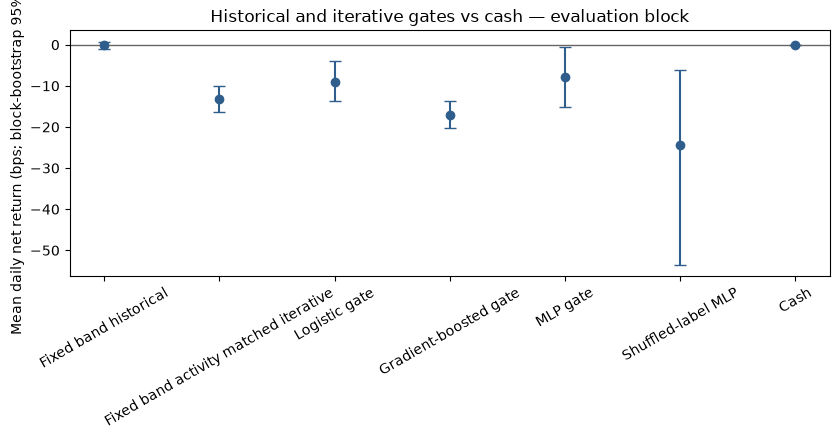

{
  "target": "whether oriented negative-share rank earns positive ar_open_h1",
  "fit": "<=2017-12-31",
  "validation": "2018-01-01..2019-12-31",
  "evaluation": ">=2020-01-01 chronological evaluation block",
  "models": [
    "fixed_band_historical",
    "fixed_band_activity_matched_iterative",
    "logistic",
    "gradient_boosted",
    "mlp",
    "mlp_label_shuffle",
    "cash"
  ],
  "features": [
    "oriented_rank",
    "abs_oriented_rank",
    "log_article_count",
    "dispersion",
    "mean_continuous",
    "firm_baseline",
    "cs_mean",
    "ret_lag1"
  ],
  "cost_bps_per_side": 10.0,
  "cutoff_selection_constraints": {
    "minimum_mean_active_names": 5.0,
    "minimum_active_session_share": 0.5
  },
  "next_sample_fixed_band": {
    "band": 0.0,
    "uses_same_activity_floor_as_learned_gates": true,
    "recomputed_on_open_evaluation_block": true,
    "result_status": "iterative_retrospective"
  },
  "bootstrap": {
    "block_length": 20,
    "replications": 999,
    "seed

In [7]:
surface_base = validation[["article_count", "dispersion"]].copy()
surface_base["story_count_bin"] = pd.cut(
    surface_base["article_count"],
    bins=[0, 1, 5, 20, 75, np.inf],
    labels=["1", "2-5", "6-20", "21-75", "76+"],
)
surface_base["dispersion_quintile"] = pd.qcut(surface_base["dispersion"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5])
surface_rows = []
for spec in frozen:
    name = spec["model"]
    local = surface_base.copy()
    local["trade_probability"] = probabilities[(name, "validation")]
    grouped = (
        local.groupby(["story_count_bin", "dispersion_quintile"], observed=True)
        .agg(mean_trade_probability=("trade_probability", "mean"), n=("trade_probability", "size"))
        .reset_index()
    )
    grouped.insert(0, "model", name)
    grouped["frozen_probability_cutoff"] = spec["probability_cutoff"]
    surface_rows.append(grouped)
surface = pd.concat(surface_rows, ignore_index=True)
surface.to_csv(OUTPUT / "learned_threshold_surfaces.csv", index=False)

feasibility = pd.DataFrame(
    [
        {
            "variant": "pooled",
            "status": "COMPLETED",
            "reason": "wide FNSPID panel supports pooled development fitting",
        },
        {
            "variant": "per_sector",
            "status": "BLOCKED_MISSING_INPUT",
            "reason": "no explicit point-in-time sector map exists for the 570-symbol FNSPID panel",
        },
        {
            "variant": "per_stock",
            "status": "NOT_RUN_BY_PREDECLARED_ORDER",
            "reason": "protocol requires sector-conditioned before stock-specific thresholds",
        },
    ]
)
feasibility.to_csv(OUTPUT / "threshold_granularity_feasibility.csv", index=False)
display(feasibility)

fig, ax = plt.subplots(figsize=(8.5, 4.5))
plot = evaluation_table.set_index("arm")
point = 1e4 * plot["mean_net"]
ax.errorbar(
    range(len(plot)),
    point,
    yerr=[point - 1e4 * plot["net_mean_ci_low"], 1e4 * plot["net_mean_ci_high"] - point],
    fmt="o",
    color="#2f5d8c",
    capsize=4,
)
ax.axhline(0, color="#666", lw=1)
ax.set_xticks(range(len(plot)))
ax.set_xticklabels([display_label(name) for name in plot.index])
ax.set_ylabel("Mean daily net return (bps; block-bootstrap 95% CI)")
ax.set_title("Historical and iterative gates vs cash — evaluation block")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
fig.savefig(OUTPUT / "evaluation_gate_comparison.png", dpi=150)
plt.show()

manifest = {
    "target": "whether oriented negative-share rank earns positive ar_open_h1",
    "fit": "<=2017-12-31",
    "validation": "2018-01-01..2019-12-31",
    "evaluation": ">=2020-01-01 chronological evaluation block",
    "models": [
        "fixed_band_historical",
        "fixed_band_activity_matched_iterative",
        "logistic",
        "gradient_boosted",
        "mlp",
        "mlp_label_shuffle",
        "cash",
    ],
    "features": list(FEATURES),
    "cost_bps_per_side": 10.0,
    "cutoff_selection_constraints": {
        "minimum_mean_active_names": MIN_MEAN_ACTIVE,
        "minimum_active_session_share": MIN_ACTIVE_SESSION_SHARE,
    },
    "next_sample_fixed_band": {
        "band": activity_matched_fixed_band,
        "uses_same_activity_floor_as_learned_gates": True,
        "recomputed_on_open_evaluation_block": True,
        "result_status": "iterative_retrospective",
    },
    "bootstrap": {"block_length": 20, "replications": 999, "seed": SEED},
    "portfolio_normalization": "surviving long and short rank legs each normalized to 0.5 gross; one-sided selections go flat",
    "evaluation_read_history": {
        "total": 4,
        "valid_historical": 1,
        "iterative_post_change": 1,
        "invalid": 2,
        "invalid_reasons": [
            "pre-repair one-sided gate exposure",
            "pre-repair threshold backtest omitted final liquidation cost",
        ],
    },
    "sector_variant": "BLOCKED_MISSING_FNSPID_SECTOR_MAP",
    "stock_variant": "NOT_RUN_BECAUSE_SECTOR_FIRST_RULE_IS_BINDING",
}
(OUTPUT / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
print(json.dumps(manifest, indent=2))